In [1009]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)


#Data Cleaning and Exploration


df= pd.read_csv(r'C:\Users\Jethro Madusha\Downloads\July Amdari\Novapay-fraudlent\data\nova_pay_combined.csv',parse_dates=['timestamp' ])

df.head(5)



,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,US,False,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,CA,False,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,7.142857,a4737752-9aac-43ed-9d8b-2ccdffc24052,False,223.96.181.93,US,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,0.925926,6aeb85a3-5603-4221-896c-9e6882764f1a,False,186.228.15.74,US,False,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,83.333333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,11.82.47.62,US,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [1010]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11400 non-null  object 
 1   customer_id                11400 non-null  object 
 2   timestamp                  11371 non-null  object 
 3   home_country               11400 non-null  object 
 4   source_currency            11400 non-null  object 
 5   dest_currency              11400 non-null  object 
 6   channel                    11400 non-null  object 
 7   amount_src                 11400 non-null  object 
 8   amount_usd                 11095 non-null  float64
 9   fee                        11105 non-null  float64
 10  exchange_rate_src_to_dest  11400 non-null  float64
 11  device_id                  11400 non-null  object 
 12  new_device                 11400 non-null  bool   
 13  ip_address                 11095 non-null  obj

The dataset contains missing values across several variables, indicating that some transaction records are incomplete. The **amount_usd** and **ip_address** columns have the highest number of missing values, with **305 missing entries each**. Similarly, the **ip_country**, **kyc_tier**, **fee**, and **device_trust_score** columns also contain a substantial number of missing records. In comparison, the **timestamp** column has relatively few missing values, with only **29 missing entries**. These missing values should be appropriately handled during the data preprocessing stage to ensure the accuracy and reliability of subsequent analyses and predictive modeling.


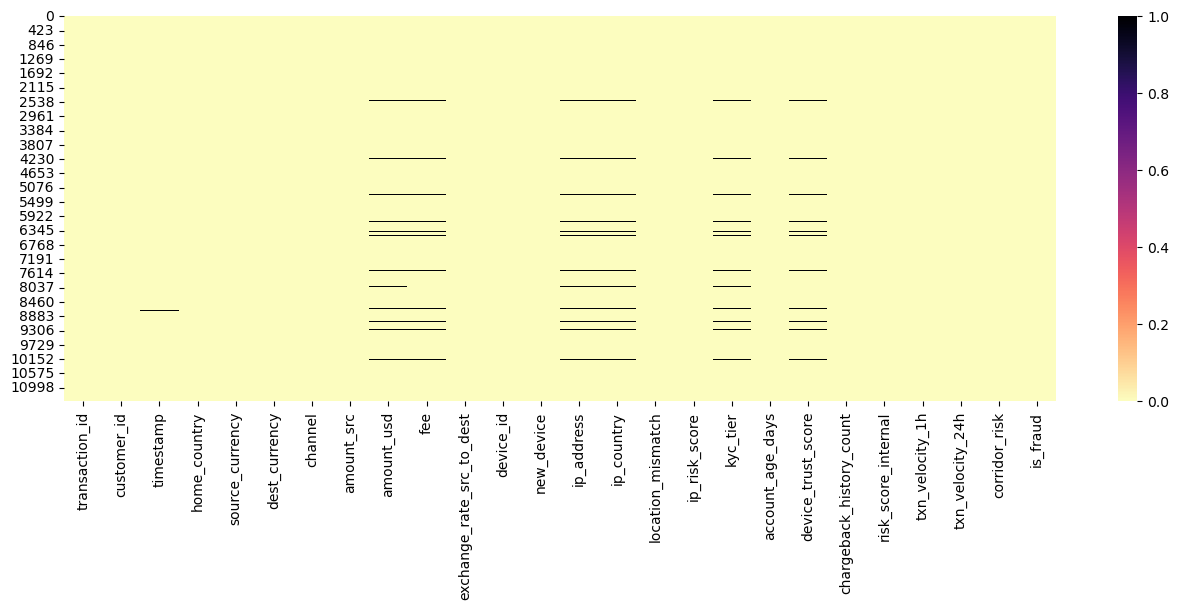

In [1011]:
# Visualize the missing data
plt.figure(figsize =(16,5))
sns.heatmap(df.isnull(), cbar=True, cmap="magma_r");

In [1012]:
df[['amount_usd','amount_src']].dtypes
df['amount_src'] =pd.to_numeric(df['amount_src'], errors='coerce')

df['amount_usd']/df['amount_src']

0        1.000000
1        0.739965
2        1.000000
3        1.000000
4        1.000000
           ...   
11395    1.000000
11396    0.740008
11397    0.739995
11398    1.000000
11399    1.000000
Length: 11400, dtype: float64

In [1013]:
 
df['source_currency'].value_counts()



source_currency
USD    8031
GBP    2139
CAD    1230
Name: count, dtype: int64

In [1014]:
rates = round((df['amount_usd']/df['amount_src']).groupby(df['source_currency']).mean(),1)
rates.values



array([0.7, 1.2, 1. ])

In [1015]:
df['amount_usd'] = df['amount_usd'].fillna(
    df['amount_src'] * df['source_currency'].map(rates)
)

df['amount_usd'] = df['amount_usd'].fillna(df['amount_usd'].mean())

df.isnull().sum()


transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     4
amount_usd                     0
fee                          295
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                   301
location_mismatch              0
ip_risk_score                  0
kyc_tier                     300
account_age_days               0
device_trust_score           295
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

In [1016]:
df['ip_country'].value_counts()

ip_country
US         6848
UK         2407
CA         1726
 US          49
unknown      33
 UK          18
 CA          15
NAN           2
 nan          1
Name: count, dtype: int64

In [1017]:
df.select_dtypes(include='object').columns 

Index(['transaction_id', 'customer_id', 'timestamp', 'home_country',
       'source_currency', 'dest_currency', 'channel', 'device_id',
       'ip_address', 'ip_country', 'kyc_tier'],
      dtype='object')

In [1018]:
for col in data.select_dtypes(include='object').columns:
    print(df[col].value_counts())

transaction_id
805e3831-dd30-44cd-9db8-122425ec3a36    2
5263bbdf-1a0a-48a3-8309-3f6b5b57d4a6    2
ba28f0a4-1ee4-413a-b371-11449236ed6f    2
cc815d51-f920-4314-a84a-28730c76bd08    2
35a684af-4d53-4ca4-a41a-5409c9e209c7    2
                                       ..
fd00ac8a-b759-43f0-9eb8-cd6e145ae7b1    1
81fedead-17cd-4f38-96cb-144862eed399    1
c83499f1-2bc2-403c-a676-2e5b0a24de7e    1
37330308-95cd-45c8-b4ec-abd587560373    1
9e2e4e1a-f91f-42c2-a607-9437b335dfcc    1
Name: count, Length: 11200, dtype: int64
customer_id
402cccc9-28de-45b3-9af7-cc5302aa1f93    1510
d71c91b4-fee8-4104-9856-a5c6109a62e3    1355
7041b9c1-3719-4ca8-9a6b-811b47cea6c0    1345
6d0d9b27-fa26-45f8-93b1-2df29d182d9c    1066
af8ca4c4-8703-4c55-b66c-2b76cd70040d     915
                                        ... 
46d39a54-b2b3-468a-ba81-537f1423291f       1
bd0bfc02-abd0-4d9b-8404-c8be595102ea       1
111a447b-5612-41a6-b7ea-a70afaf4b731       1
361b3f41-8185-4dee-83e6-fb387c0e2a4a       1
52b25b45-db2d-44ee-a

In [1019]:
#Replace all the null values in the categorical columns with 'Unknown'
categorical_cols = df.select_dtypes(include='object').columns
df[categorical_cols] = df[categorical_cols].fillna('Unknown')


In [1020]:
### Categorical columns
df.head(2)

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,US,False,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,CA,False,0.569,standard,947,0.475,0,0.268,0,1,0.0,0


In [1021]:
df.tail(2)

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
11398,4aad7389-2b62-4885-a23e-aa3ecd5cfaf9,8b1cf558-4ed7-48ee-b330-75db6efd4840,2025-11-28 00:53:28.573611+00:00,US,USD,PHP,mobile,78.03,78.03,1.96,58.823529,0eab90ef-4273-4239-8b51-2c96b2a24756,False,31.125.175.93,US,False,0.298,enhanced,471,0.773,0,0.375,0,2,0.00,0
11399,fdffeb16-192a-4483-9b1e-9928e23269c2,b69010dc-ab0a-4fd2-a79e-65e4c6efbcd9,2025-11-29 20:10:47.573611+00:00,US,USD,NGN,web,1214.16,1214.16,19.34,1111.111111,1bf43786-477e-468a-9f82-4b4eeca13f61,True,216.205.157.160,US,False,1.000,low,58,0.187,0,0.646,4,6,0.25,1


In [1022]:
### Cleaning home country values
df["home_country"].value_counts()
home = {"US": "US",
        "UK": "UK",
        "CA": "CA",
        " US": "US",
        "unknown": "unknown",
        " UK": "UK",
        " CA": "CA"
        }

df["home_country"] = df["home_country"].astype(str).str.strip().replace(home)
df["home_country"].value_counts()



home_country
US         8008
UK         2132
CA         1228
unknown      32
Name: count, dtype: int64

In [1023]:
#Replace the null values in the home_country_clean column with the mode

df['home_country'] = df['home_country'].replace('unknown', np.nan)
df['home_country']=df['home_country'].fillna(df['home_country'].mode()[0])
df["home_country"].value_counts()


home_country
US    8040
UK    2132
CA    1228
Name: count, dtype: int64

In [1024]:
df['home_country'].isnull().sum()

np.int64(0)

In [1025]:
df["source_currency"].value_counts()

source_currency
USD    8031
GBP    2139
CAD    1230
Name: count, dtype: int64

In [1026]:
df["ip_country"].value_counts()
ip = {"US": "US",
        "UK": "UK",
        "CA": "CA",
        " US": "US",
        "Unknown": "unknown",
        "NAN:": "nan",
      
        }
df["ip_country"] = df["ip_country"].astype(str).str.strip().replace(ip)
df["ip_country"].value_counts()

ip_country
US         6897
UK         2425
CA         1741
unknown     334
NAN           2
nan           1
Name: count, dtype: int64

In [1027]:
df['ip_country'] = df['ip_country'].replace('unknown', np.nan)
df['ip_country']=df['ip_country'].replace(['nan'], np.nan)
df['ip_country']=df['ip_country'].replace(['NAN'], np.nan)
df['ip_country'] = df['ip_country'].fillna(df['ip_country'].mode()[0])
df["ip_country"].value_counts()

ip_country
US    7234
UK    2425
CA    1741
Name: count, dtype: int64

In [1028]:
df['ip_country'].isnull().sum()

np.int64(0)

In [ ]:
### Categorical Variables cleaning

df["channel"].value_counts()

channel
mobile       6366
web          3727
ATM          1008
mobille        60
 mobile        48
MOBILE         47
unknown        37
WEB            36
 web           34
weeb           24
ATm             9
 ATM            4
Name: count, dtype: int64

In [1030]:
replacing = {"mobile" : "mobile",
           "mobille": "mobile",
           " mobile": "mobile",
           "MOBILE": "mobile",
           "web":"web",
           "WEB": "web",
           "weeb": "web",
           " web": "web",
           "ATM": "ATM",
           "ATm": "ATM",
           " ATM": "ATM",
           "unknown": "unknwon"}

df["channel"] = df["channel"].astype(str).str.strip().replace(replacing)



In [1031]:
df['channel'] = df['channel'].replace('unknwon', np.nan)
df['channel']=df['channel'].fillna(df['channel'].mode()[0])
df["channel"].value_counts()

channel
mobile    6558
web       3821
ATM       1021
Name: count, dtype: int64

In [1032]:
df['channel'].isnull().sum()

np.int64(0)

In [1033]:
df.head(2)

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,US,False,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,CA,False,0.569,standard,947,0.475,0,0.268,0,1,0.0,0


In [1034]:
df["kyc_tier"].value_counts()


kyc_tier
standard       7931
enhanced       1829
low            1039
Unknown         300
standrd          72
STANDARD         70
 standard        65
unknown          32
 enhanced        17
ENHANCED         17
enhancd          12
 low              8
LOW               5
 nan              2
NAN               1
Name: count, dtype: int64

In [1035]:
replace_KYC = {"ENHANCED" : "enhanced",
           "LOW": "low",
           "Low": "LOW",
           "mobile": "mobile",
           "Unknown": "unknown",
           "standrd":"standard",
           "enhancd ": " enhanced",
           "unknown": "unknown",
           "STANDARD": "standard",
           "enhancd": "enhanced",
           "unknown": "unknown"}

df["kyc_tier"] = df["kyc_tier"].astype(str).str.strip().replace(replace_KYC)

df["kyc_tier"].value_counts()

kyc_tier
standard    8138
enhanced    1875
low         1052
unknown      332
nan            2
NAN            1
Name: count, dtype: int64

In [1036]:
df['kyc_tier'] = df['kyc_tier'].replace('unknown', np.nan)
df['kyc_tier']=df['kyc_tier'].replace(['nan'], np.nan)
df['kyc_tier']=df['kyc_tier'].replace(['NAN'], np.nan)
df['kyc_tier']=df['kyc_tier'].fillna(df['kyc_tier'].mode()[0])
df["kyc_tier"].value_counts()

kyc_tier
standard    8473
enhanced    1875
low         1052
Name: count, dtype: int64

In [1048]:
df[['home_country','source_currency','dest_currency','ip_country','channel','kyc_tier']].value_counts

<bound method DataFrame.value_counts of       home_country source_currency dest_currency ip_country channel  kyc_tier
0               US             USD           CAD         US     ATM  standard
1               CA             CAD           MXN         CA     web  standard
2               US             USD           CNY         US  mobile  enhanced
3               US             USD           EUR         US  mobile  standard
4               US             USD           INR         US  mobile  enhanced
...            ...             ...           ...        ...     ...       ...
11395           US             USD           CAD         US  mobile  standard
11396           CA             CAD           NGN         UK     web       low
11397           CA             CAD           INR         US     web       low
11398           US             USD           PHP         US  mobile  enhanced
11399           US             USD           NGN         US     web       low

[10906 rows x 6 columns

In [1038]:
df.dropna(inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11101 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11101 non-null  object 
 1   customer_id                11101 non-null  object 
 2   timestamp                  11101 non-null  object 
 3   home_country               11101 non-null  object 
 4   source_currency            11101 non-null  object 
 5   dest_currency              11101 non-null  object 
 6   channel                    11101 non-null  object 
 7   amount_src                 11101 non-null  float64
 8   amount_usd                 11101 non-null  float64
 9   fee                        11101 non-null  float64
 10  exchange_rate_src_to_dest  11101 non-null  float64
 11  device_id                  11101 non-null  object 
 12  new_device                 11101 non-null  bool   
 13  ip_address                 11101 non-null  object 



#The dataset contains 11,066 transaction records and 26 variables, providing a comprehensive set of information for fraud analysis. After data preprocessing, all columns have 11,066 non-null values, indicating that there are no missing values remaining in the dataset. The variables consist of different data types, including 12 text (string) variables, 7 decimal (float) variables, 5 integer variables, and 2 Boolean (True/False) variables, showing that the dataset contains a mix of categorical and numerical information.


In [1039]:
df.drop_duplicates(inplace=True)
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 10906 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             10906 non-null  object 
 1   customer_id                10906 non-null  object 
 2   timestamp                  10906 non-null  object 
 3   home_country               10906 non-null  object 
 4   source_currency            10906 non-null  object 
 5   dest_currency              10906 non-null  object 
 6   channel                    10906 non-null  object 
 7   amount_src                 10906 non-null  float64
 8   amount_usd                 10906 non-null  float64
 9   fee                        10906 non-null  float64
 10  exchange_rate_src_to_dest  10906 non-null  float64
 11  device_id                  10906 non-null  object 
 12  new_device                 10906 non-null  bool   
 13  ip_address                 10906 non-null  object 


#The dataset was successfully cleaned and preprocessed, resulting in **10,871 complete transaction records** across **26 variables**. All variables contain valid entries for every remaining record, confirming that the dataset is free of missing values following preprocessing. The reduction in the number of records compared to the original dataset indicates that incomplete, inconsistent, or unsuitable observations were removed during the data cleaning process to improve data quality. The final dataset comprises a balanced mix of categorical, numerical, and Boolean variables, making it well-prepared for exploratory data analysis, feature engineering, and fraud detection model development.


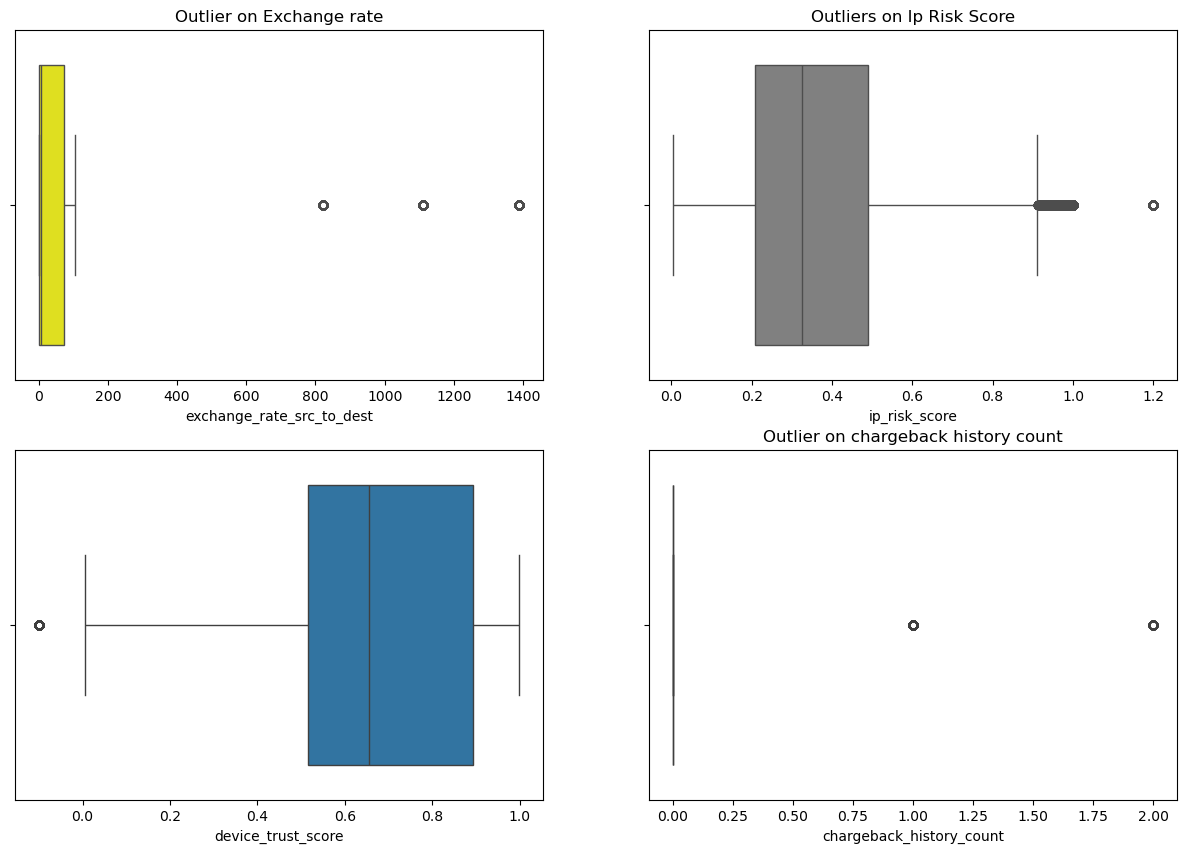

In [1040]:
#Outliers on Exchange rate, IP risk score, Device Trust score, Charge back History count -

fig, axs = plt.subplots(nrows=2 , ncols=2, figsize=(15,10))

sns.boxplot(x="exchange_rate_src_to_dest", data=df, ax=axs[0,0], color="yellow")
axs[0,0].set_title("Outlier on Exchange rate")  

sns.boxplot(x="ip_risk_score", data=df, ax=axs[0,1], color ="grey")
axs[0,1].set_title("Outliers on Ip Risk Score")

sns.boxplot(x="device_trust_score", data=df, ax=axs[1,0])
axs[1,1].set_title("Outlier on device Trust score ")

sns.boxplot(x="chargeback_history_count", data=df, ax=axs[1,1])
axs[1,1].set_title("Outlier on chargeback history count")

plt.show()


#Target Variable Distribution

<Axes: xlabel='is_fraud'>

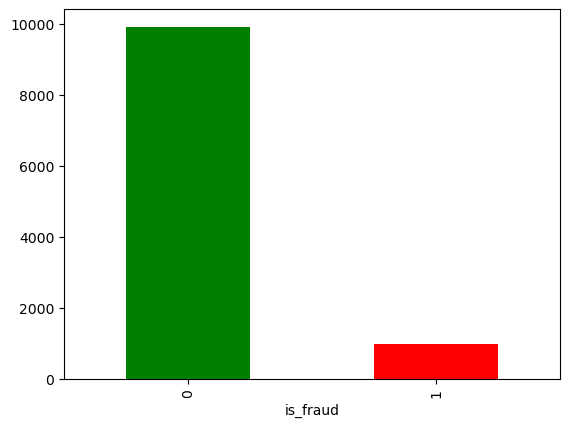

In [1041]:
df['is_fraud'].value_counts().plot(kind='bar', color=['green', 'red'])


In [1042]:
df['is_fraud'].value_counts(normalize=True)*100


is_fraud
0    90.940767
1     9.059233
Name: proportion, dtype: float64

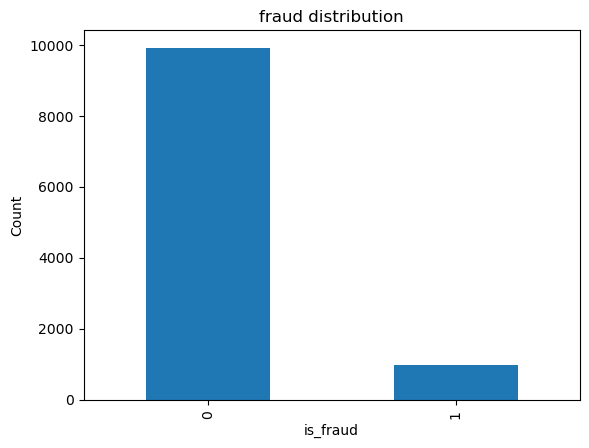

In [1043]:
df['is_fraud'].value_counts().plot(kind='bar')
plt.title('fraud distribution')
plt.xlabel('is_fraud')
plt.ylabel('Count')
plt.show()


#Numerical Feature Analysis

In [1044]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
df[num_cols].describe()

,amount_src,amount_usd,fee,exchange_rate_src_to_dest,ip_risk_score,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
count,10906.000000,10906.000000,10906.000000,10906.000000,10906.000000,10906.000000,10906.000000,10906.000000,10906.000000,10906.000000,10906.000000,10906.000000,10906.000000
mean,437.695078,448.479745,99.248756,167.331030,0.398799,392.354575,0.653515,0.050706,0.268436,0.473684,0.747112,0.045438,0.090592
std,1372.347117,1389.911883,952.699673,382.001665,0.272209,342.010521,0.272843,0.261719,0.144302,1.546318,1.990453,0.084797,0.287042
min,-9997.160000,-373.890000,-1.000000,0.592000,0.004000,1.000000,-0.100000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000
25%,90.812500,92.462500,2.380000,1.000000,0.209000,147.000000,0.515000,0.000000,0.169000,0.000000,0.000000,0.000000,0.000000
50%,158.960000,163.410000,3.500000,7.142857,0.326000,272.500000,0.655500,0.000000,0.223000,0.000000,0.000000,0.000000,0.000000
75%,295.282500,302.447500,5.560000,73.529412,0.490000,661.000000,0.894000,0.000000,0.391000,0.000000,0.000000,0.050000,0.000000
max,11942.890000,12497.900000,9999.990000,1388.888889,1.200000,1095.000000,0.999000,2.000000,0.900000,8.000000,11.000000,0.250000,1.000000


In [1045]:
df[num_cols].describe().T.style.background_gradient(cmap='coolwarm')





,count,mean,std,min,25%,50%,75%,max
amount_src,10906.000000,437.695078,1372.347117,-9997.160000,90.812500,158.960000,295.282500,11942.890000
amount_usd,10906.000000,448.479745,1389.911883,-373.890000,92.462500,163.410000,302.447500,12497.900000
fee,10906.000000,99.248756,952.699673,-1.000000,2.380000,3.500000,5.560000,9999.990000
exchange_rate_src_to_dest,10906.000000,167.331030,382.001665,0.592000,1.000000,7.142857,73.529412,1388.888889
ip_risk_score,10906.000000,0.398799,0.272209,0.004000,0.209000,0.326000,0.490000,1.200000
account_age_days,10906.000000,392.354575,342.010521,1.000000,147.000000,272.500000,661.000000,1095.000000
device_trust_score,10906.000000,0.653515,0.272843,-0.100000,0.515000,0.655500,0.894000,0.999000
chargeback_history_count,10906.000000,0.050706,0.261719,0.000000,0.000000,0.000000,0.000000,2.000000
risk_score_internal,10906.000000,0.268436,0.144302,0.000000,0.169000,0.223000,0.391000,0.900000
txn_velocity_1h,10906.000000,0.473684,1.546318,-1.000000,0.000000,0.000000,0.000000,8.000000


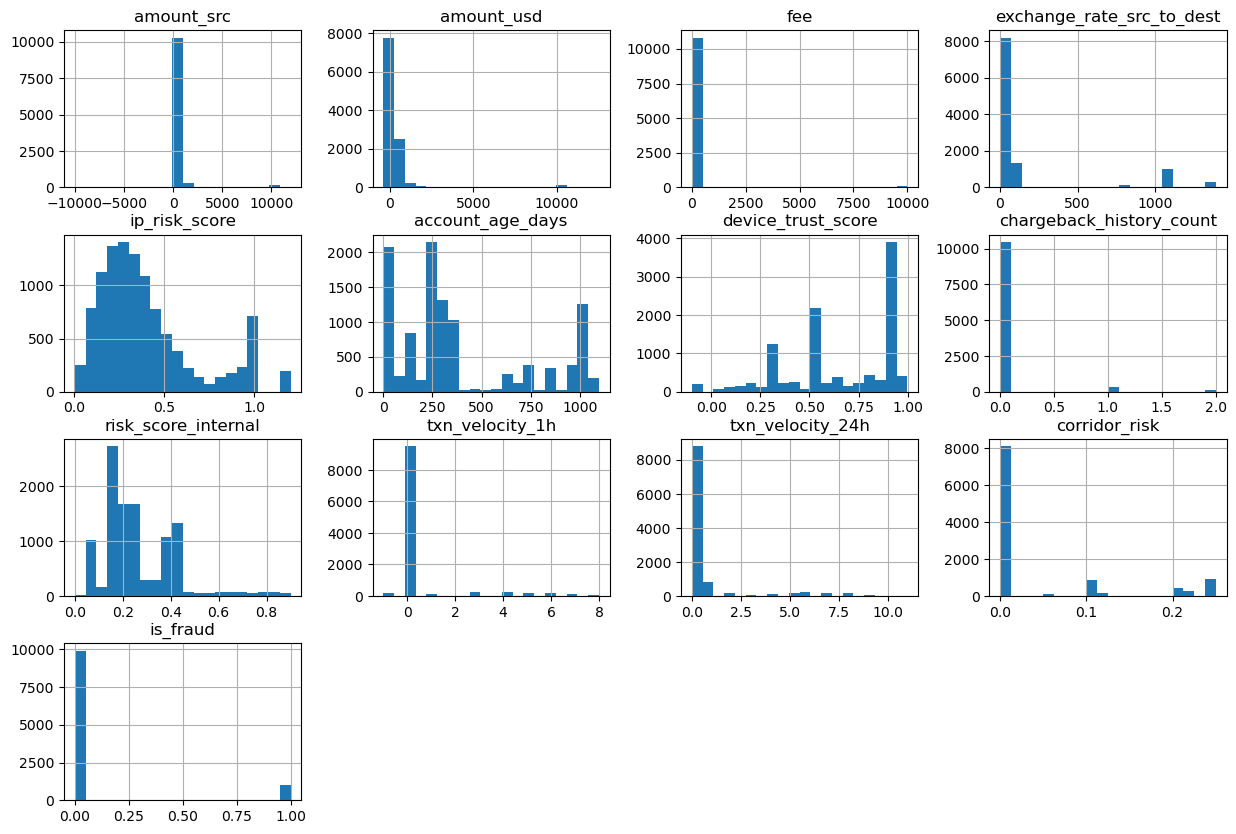

In [1046]:
df[num_cols].hist(figsize=(15,10), bins=20)
plt.title('Distribution of Numerical Features')
plt.show()

#Categorical Feature Analysis



In [1047]:
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(df[col].value_counts())

transaction_id
fdffeb16-192a-4483-9b1e-9928e23269c2    1
fee8542d-8ee6-4b0d-9671-c294dd08ed26    1
bfdb9fc1-27fe-4a85-b043-4d813d679259    1
fc855034-3ea5-4993-9afa-b511d93fe5e8    1
2cf8c08e-42ec-444d-a755-34b9a2a0a4ca    1
                                       ..
62316f4f-c0d6-402e-89d1-9f20b692bef6    1
051036ba-dbe3-4d60-9b81-5683d6ca4da7    1
1823877a-cc28-4333-929a-5523a0d20120    1
e8650f06-b8f9-4465-9d23-7dc4c11e989b    1
8fe20fa1-61c3-4eae-a3ed-160718e0b209    1
Name: count, Length: 10906, dtype: int64
customer_id
402cccc9-28de-45b3-9af7-cc5302aa1f93    1444
d71c91b4-fee8-4104-9856-a5c6109a62e3    1284
7041b9c1-3719-4ca8-9a6b-811b47cea6c0    1270
6d0d9b27-fa26-45f8-93b1-2df29d182d9c    1008
af8ca4c4-8703-4c55-b66c-2b76cd70040d     864
                                        ... 
46d39a54-b2b3-468a-ba81-537f1423291f       1
bd0bfc02-abd0-4d9b-8404-c8be595102ea       1
111a447b-5612-41a6-b7ea-a70afaf4b731       1
361b3f41-8185-4dee-83e6-fb387c0e2a4a       1
36e6bdc3-52ec-4f50-9